<a href="https://colab.research.google.com/github/msiam71/RainfallSarimaModel/blob/main/Rainfall_Sarima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.dates as mdates
from google.colab import drive

In [7]:

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Bangladesh_Monthly_Rainfall_GAUL.csv')

In [9]:
df = df[['year','month','rainfall_mm']]

In [20]:
# make datetime index
df['Date'] = pd.to_datetime(df[['year','month']].assign(day=1))
df.set_index('Date', inplace=True)

In [21]:
# keep only 2010–2024
rainfall = df.loc['2010-01-01':'2024-12-01', 'rainfall_mm']

In [22]:
# fit sarima
model = SARIMAX(rainfall, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



In [23]:
#forecast next 24 months
forecast = results.get_forecast(steps=24)
pred = forecast.predicted_mean
conf = forecast.conf_int()

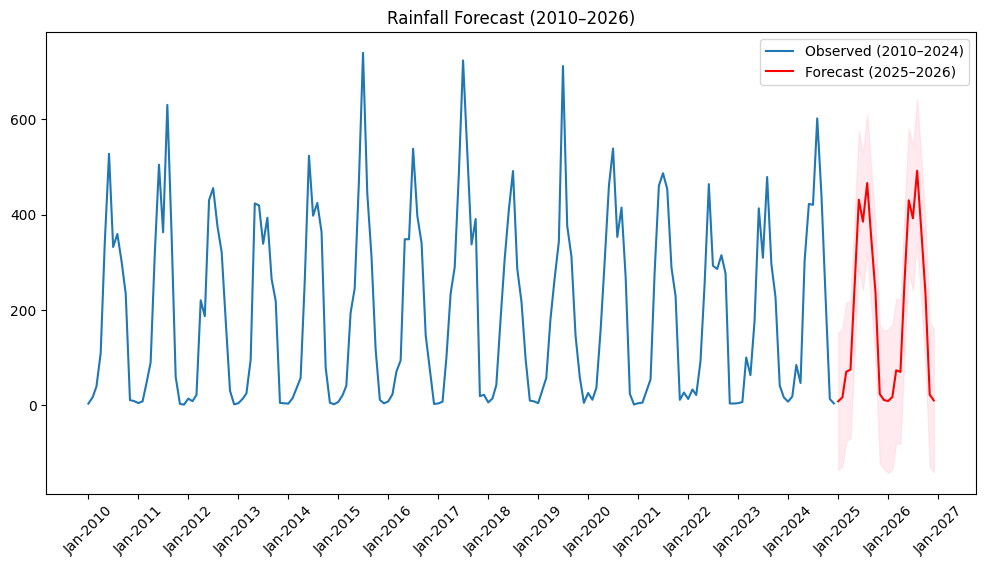

In [24]:
# plot
plt.figure(figsize=(12,6))
plt.plot(rainfall, label="Observed (2010–2024)")
plt.plot(pred, label="Forecast (2025–2026)", color="red")
plt.fill_between(conf.index, conf.iloc[:,0], conf.iloc[:,1], color="pink", alpha=0.3)

# format x axis: show months+years
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)

plt.legend()
plt.title("Rainfall Forecast (2010–2026)")
plt.show()

In [25]:
### for better monthly rainfall observation(graph/plot)
import plotly.express as px

#combine observed + forecast into one
df_plot = pd.DataFrame({
    "Date": rainfall.index,
    "Rainfall": rainfall.values,
    "Type": "Observed"
})
df_forecast = pd.DataFrame({
    "Date": pred.index,
    "Rainfall": pred.values,
    "Type": "Forecast"
})
df_all = pd.concat([df_plot, df_forecast])

# interactive line plot
fig = px.line(df_all, x="Date", y="Rainfall", color="Type", title="Rainfall Forecast (2010–2026)")
fig.update_xaxes(dtick="M12", tickformat="%b-%Y")  # show years with month
fig.show()
